# Assessment Lab — ML Model Robustness with ART + Optuna

**Module:** NVIDIA DLI 'Exploring Adversarial Machine Learning' — Module 4: Security / Model Assessment  
**Lab folder:** `assessment/art-robustness-assessment/`

---

## What this lab assesses

This notebook is a **security assessment report** for a digit-classifying MLP.
Unlike the other modules in this portfolio (evasion, extraction, inversion, poisoning),
the Assessment module is **not a sixth attack family** — it is the methodology and tooling
layer that Module 4 teaches as standard practice for evaluating any ML system:

| Tool | Role in this lab |
|------|------------------|
| **Adversarial Robustness Toolbox (ART)** | Black-box robustness probe via HopSkipJump (label-only, no gradients) |
| **Optuna** | Attacks as hyperparameter optimisation — find the gentlest effective attack |

**Central question:** How hard is it to fool this model, and can we find attack settings
that do so more efficiently (smaller perturbation, same fooling power)?

In [1]:
import sys, os, pickle, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import HopSkipJump

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning)

# The notebook lives in notebooks/; the lab root is one level up.
# Inserting it into sys.path lets us import metrics.py without copying it.
LAB_ROOT = Path('..').resolve()
sys.path.insert(0, str(LAB_ROOT))
from metrics import asr, l2_perturbation, robustness_curve

print(f'Lab root : {LAB_ROOT}')
print('Imports OK.')

C:\Users\Hasina Rindra\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Hasina Rindra\AppData\Roaming\Python\Python314\site-packages\art\estimators\certification\__init__.py:30: UserWarning: PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality
  warnings.warn("PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality")


Lab root : C:\Users\Hasina Rindra\adversarial-ml\assessment\art-robustness-assessment
Imports OK.


## The Model Under Assessment

**Architecture:** `MLPClassifier(hidden_layer_sizes=(64, 32))`  
**Dataset:** scikit-learn `digits` — 1 797 samples, 64 features (8×8 grayscale pixels), 10 classes (0–9)  
**Pre-processing:** pixel values divided by 16 to map the raw [0, 16] range into [0, 1]  
**Split:** 80 / 20 train / test, `random_state=42`

The model is intentionally small and CPU-friendly. The assessment goal is to demonstrate
the **workflow** — the same pipeline applies to any sklearn-compatible classifier.

In [2]:
# Load and normalise
digits = load_digits()
X = digits.data / 16.0   # map [0, 16] -> [0, 1]; ART requires inputs inside clip_values
y = digits.target

# Deterministic split -- matches train_target.py exactly so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a small two-hidden-layer MLP
model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))
print(f'Train accuracy : {train_acc:.4f}')
print(f'Test  accuracy : {test_acc:.4f}')

# Persist to models/ so the cells below can reload the same split if needed
os.makedirs(LAB_ROOT / 'models', exist_ok=True)
with open(LAB_ROOT / 'models' / 'target_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(LAB_ROOT / 'models' / 'test_split.pkl', 'wb') as f:
    pickle.dump({'X_test': X_test, 'y_test': y_test}, f)

Train accuracy : 1.0000
Test  accuracy : 0.9722


---
## Act 1 — Black-Box Robustness Assessment (ART / HopSkipJump)

**HopSkipJump** (Chen et al., 2020) is a *decision-based* attack: it queries the model
for its predicted **label only** — no gradients, no probabilities. This mirrors a realistic
attacker who can call a model API but cannot inspect its weights or architecture.

**Protocol:**
- Wrap the model in ART's `SklearnClassifier` with `clip_values=(0.0, 1.0)`  
- Attack config: `norm=2`, `max_iter=15`, `max_eval=1000`, `init_eval=10`  
- **5 random seeds** — each subsamples 50 test points, attacks only the ones originally
  classified correctly, and records ASR + L2 perturbation + query count  
- Summary reported as **mean ± std** across seeds (multi-seed honesty)

In [3]:
# ── ART wrapper (created once; reused across all cells) ───────────────────────
art_classifier = SklearnClassifier(model=model, clip_values=(0.0, 1.0))
_real_predict  = art_classifier.predict   # saved before any monkey-patching

# ── Shared attack runner ──────────────────────────────────────────────────────
# Defined here so cells 11 and 12 (Optuna) can call it without duplication.
# Returns a dict of metrics + raw arrays, or None if no correct samples.
def run_attack(max_iter, max_eval, init_eval, seed, n_points, init_size=100):
    np.random.seed(seed)
    idx   = np.random.choice(len(X_test), size=min(n_points, len(X_test)), replace=False)
    X_sub, y_sub = X_test[idx], y_test[idx]

    orig_preds   = np.argmax(art_classifier.predict(X_sub), axis=1)
    correct_mask = (orig_preds == y_sub)
    X_correct, y_correct = X_sub[correct_mask], y_sub[correct_mask]
    orig_correct = orig_preds[correct_mask]
    n_correct    = len(X_correct)
    if n_correct == 0:
        return None

    # Count queries via monkey-patch (same technique as art_assessment.py)
    query_count = [0]
    def _cp(x, **kw): query_count[0] += len(x); return _real_predict(x, **kw)
    art_classifier.predict = _cp

    attack = HopSkipJump(classifier=art_classifier, targeted=False, norm=2,
                         max_iter=max_iter, max_eval=max_eval,
                         init_eval=init_eval, init_size=init_size)
    X_adv = attack.generate(x=X_correct)

    try:    delattr(art_classifier, 'predict')
    except AttributeError: art_classifier.predict = _real_predict

    adv_preds    = np.argmax(art_classifier.predict(X_adv), axis=1)
    success_mask = (adv_preds != orig_correct)
    trial_asr    = asr(orig_correct, adv_preds, y_correct)
    l2_vals      = l2_perturbation(X_correct, X_adv)
    mean_l2      = float(l2_vals[success_mask].mean()) if success_mask.any() else 0.0
    avg_q        = query_count[0] / n_correct

    return dict(asr=trial_asr, mean_l2=mean_l2, avg_queries=avg_q,
                X_orig=X_correct, X_adv=X_adv, orig_preds=orig_correct,
                adv_preds=adv_preds, y_true=y_correct,
                l2_vals=l2_vals, success_mask=success_mask)

# ── 5-seed assessment ─────────────────────────────────────────────────────────
SEEDS, N_SUB = [0, 1, 2, 3, 4], 50
seed_results, last_r = [], None

for seed in SEEDS:
    print(f'Seed {seed} ...', end=' ')
    r = run_attack(max_iter=15, max_eval=1000, init_eval=10, seed=seed, n_points=N_SUB)
    if r is None:
        print('skipped'); continue
    print(f"ASR={r['asr']:.3f}  L2={r['mean_l2']:.4f}  q={r['avg_queries']:.0f}")
    seed_results.append(r)
    last_r = r

asrs    = [r['asr']         for r in seed_results]
l2s     = [r['mean_l2']     for r in seed_results]
queries = [r['avg_queries'] for r in seed_results]
sep = '=' * 52
print(f'\n{sep}')
print(f'ASR           : {np.mean(asrs):.3f} +/- {np.std(asrs):.3f}')
print(f'Mean L2       : {np.mean(l2s):.4f} +/- {np.std(l2s):.4f}')
print(f'Avg queries   : {np.mean(queries):.0f} +/- {np.std(queries):.0f}')
print(sep)

Seed 0 ... 

HopSkipJump:   0%|          | 0/49 [00:00<?, ?it/s]

HopSkipJump:  10%|█         | 5/49 [00:00<00:01, 43.35it/s]

HopSkipJump:  20%|██        | 10/49 [00:00<00:00, 45.09it/s]

HopSkipJump:  31%|███       | 15/49 [00:00<00:00, 44.92it/s]

...

HopSkipJump:  73%|███████▎  | 36/49 [00:00<00:00, 47.63it/s]

HopSkipJump:  84%|████████▎ | 41/49 [00:00<00:00, 48.18it/s]

HopSkipJump:  94%|█████████▍| 46/49 [00:00<00:00, 48.34it/s]

HopSkipJump: 100%|██████████| 49/49 [00:01<00:00, 46.43it/s]

ASR=1.000  L2=0.8197  q=580

ASR           : 1.000 +/- 0.000
Mean L2       : 0.7343 +/- 0.0518
Avg queries   : 580 +/- 0


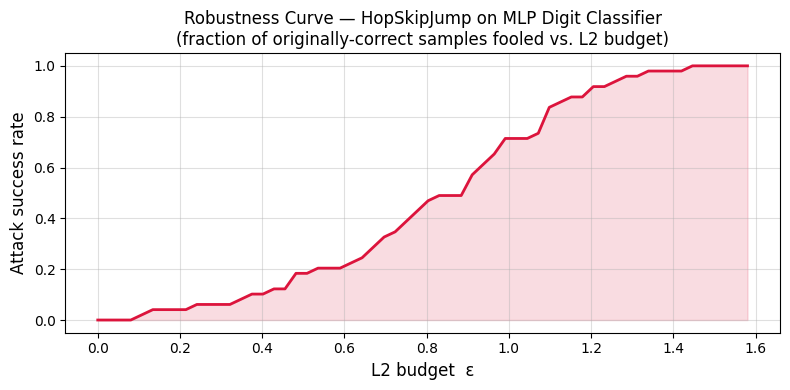

In [4]:
# Robustness curve — ASR vs L2 budget ε  (uses last seed's data)
l2_last   = last_r['l2_vals']
succ_last = last_r['success_mask']

eps_grid             = np.linspace(0, float(l2_last.max()) * 1.1 + 0.01, 60)
eps_vals, asr_at_eps = robustness_curve(l2_last, succ_last, eps_grid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_vals, asr_at_eps, color='crimson', linewidth=2)
ax.fill_between(eps_vals, asr_at_eps, alpha=0.15, color='crimson')
ax.set_xlabel('L2 budget  \u03b5', fontsize=12)
ax.set_ylabel('Attack success rate', fontsize=12)
ax.set_title(
    'Robustness Curve — HopSkipJump on MLP Digit Classifier\n'
    '(fraction of originally-correct samples fooled vs. L2 budget)'
)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

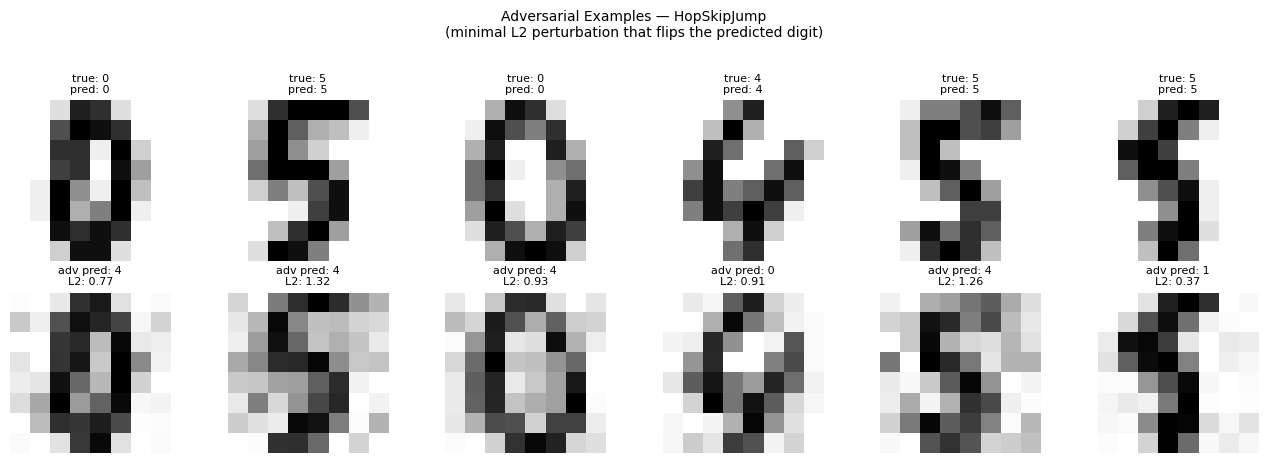

In [5]:
# Before / after image grid — originals (top) vs adversarial versions (bottom)
n_show      = min(6, int(succ_last.sum()))
success_idx = np.where(succ_last)[0][:n_show]

if n_show == 0:
    print('No successful adversarial examples to display.')
else:
    fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.5), squeeze=False)
    for col, i in enumerate(success_idx):
        axes[0, col].imshow(last_r['X_orig'][i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[0, col].set_title(
            f"true: {last_r['y_true'][i]}\npred: {last_r['orig_preds'][i]}", fontsize=8
        )
        axes[0, col].axis('off')
        axes[1, col].imshow(last_r['X_adv'][i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        axes[1, col].set_title(
            f"adv pred: {last_r['adv_preds'][i]}\nL2: {last_r['l2_vals'][i]:.2f}", fontsize=8
        )
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('Original',    fontsize=9)
    axes[1, 0].set_ylabel('Adversarial', fontsize=9)
    plt.suptitle(
        'Adversarial Examples — HopSkipJump\n'
        '(minimal L2 perturbation that flips the predicted digit)',
        fontsize=10, y=1.02
    )
    plt.tight_layout()
    plt.show()

### Reading the Baseline

**ASR ≈ 1.0 is a near-non-finding.** The digits dataset lives in a low-dimensional
space (64 features, 10 classes with narrow margins). A decision-based attack that can
move across the boundary in any direction will almost always find one. 100 % ASR on this
model says more about the problem geometry than about the model's quality.

**The L2 curve is the real result.** The robustness curve shows *how much perturbation*
the attacker needs. Most samples can be flipped with L2 ≤ ~0.8 — that is, shifting each
of the 64 pixels by an average of ~0.8/√64 ≈ 0.1 units. Small but not zero.

**Queries matter for the threat model.** Stage 1 uses ~580 queries/sample. For a
rate-limited API that is the attacker's cost floor at these settings. Act 2 asks:
can we find attack hyperparameters that achieve the same L2 (or lower) within that budget?

---
## Act 2 — Attacks as Optimisation (Optuna)

Module 4's key insight: **treat the attacker's goal as an optimisation problem**.
Instead of hand-picking HopSkipJump settings, we let Optuna's TPE sampler search
for the configuration that produces the most *efficient* attack.

**Objective to minimise:**

```
score = mean_L2
      + 5.0  × max(0, 0.95 − ASR)          # heavy penalty if ASR drops below 95 %
      + 0.001 × max(0, avg_queries − 600)   # light penalty for exceeding Stage 1 budget
```

The penalties prevent the optimiser from cheating — e.g., finding params that return
tiny L2 by simply failing to flip any predictions.

**Search space (HopSkipJump, `norm=2` fixed):**

| Parameter | Range | Note |
|-----------|-------|------|
| `max_iter` | [5, 30] | boundary-walk iterations |
| `max_eval` | [200, 1500] | gradient-direction evaluations per iter |
| `init_eval` | [1, min(100, max_eval)] | sampled after max_eval; ART requires init_eval ≤ max_eval |
| `init_size` | [1, 100] | random vectors used to find initial adversarial point |

**Sampler:** `TPESampler(seed=42)` — in-memory, no SQLite, reproducible search order.

In [6]:
N_TRIALS     = 30
N_OPT_SUB   = 30    # test points per trial (small to keep each trial fast)
QUERY_BUDGET = 600  # Stage 1 averaged ~580 q/sample; this is our ceiling

def objective(trial):
    # max_eval must be sampled FIRST — init_eval's upper bound depends on it
    max_iter  = trial.suggest_int('max_iter',  5,   30)
    max_eval  = trial.suggest_int('max_eval',  200, 1500)
    init_eval = trial.suggest_int('init_eval', 1,   min(100, max_eval))
    init_size = trial.suggest_int('init_size', 1,   100)

    r = run_attack(max_iter=max_iter, max_eval=max_eval, init_eval=init_eval,
                   seed=trial.number, n_points=N_OPT_SUB, init_size=init_size)

    if r is None or r['asr'] == 0.0:
        return 10.0   # large finite penalty; NaN/inf would crash the study

    asr_penalty   = 5.0   * max(0.0, 0.95 - r['asr'])
    query_penalty = 0.001 * max(0.0, r['avg_queries'] - QUERY_BUDGET)
    return r['mean_l2'] + asr_penalty + query_penalty

# NOTE: TPESampler(seed=42) makes the SEARCH order reproducible.
# Per-trial L2 values still vary slightly run-to-run because HopSkipJump
# samples random directions internally from the global numpy RNG.
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))

def _cb(study, trial):
    if trial.value is None: return
    mark = '  <-- best' if trial.value == study.best_value else ''
    print(f"  Trial {trial.number:>2d}: score={trial.value:.4f}  "
          f"max_iter={trial.params.get('max_iter'):>2}  "
          f"max_eval={trial.params.get('max_eval'):>4}  "
          f"init_eval={trial.params.get('init_eval'):>3}  "
          f"init_size={trial.params.get('init_size'):>3}" + mark)

print(f'Running {N_TRIALS} Optuna trials ...\n')
study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, callbacks=[_cb])

print(f'\nBest trial   : #{study.best_trial.number}')
print(f'Best score   : {study.best_value:.4f}')
print('Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:12s} = {v}')

Running 30 Optuna trials ...



HopSkipJump:   0%|          | 0/30 [00:00<?, ?it/s]

HopSkipJump:  13%|█▎        | 4/30 [00:00<00:00, 31.47it/s]

HopSkipJump:  27%|██▋       | 8/30 [00:00<00:00, 30.96it/s]

HopSkipJump:  40%|████      | 12/30 [00:00<00:00, 30.63it/s]

...

HopSkipJump:  67%|██████▋   | 20/30 [00:00<00:00, 34.93it/s]

HopSkipJump:  83%|████████▎ | 25/30 [00:00<00:00, 37.25it/s]

HopSkipJump:  97%|█████████▋| 29/30 [00:00<00:00, 37.12it/s]

HopSkipJump: 100%|██████████| 30/30 [00:00<00:00, 35.87it/s]

  Trial 29: score=0.6993  max_iter=18  max_eval=1464  init_eval=  8  init_size= 55

Best trial   : #2
Best score   : 0.6371
Best params  :
  max_iter     = 20
  max_eval     = 1121
  init_eval    = 3
  init_size    = 97


In [7]:
# Run baseline and best config on the SAME seed for a fair comparison
COMPARE_SEED    = 999
BASELINE_PARAMS = dict(max_iter=15, max_eval=1000, init_eval=10, init_size=100)

print(f'Comparing on 50 points (seed={COMPARE_SEED}) ...')
b = run_attack(**BASELINE_PARAMS, seed=COMPARE_SEED, n_points=50)
o = run_attack(**study.best_params, seed=COMPARE_SEED, n_points=50)

print()
sep = '=' * 58
print(sep)
print(f"{'config':<14} {'mean L2':>10} {'ASR':>8} {'avg queries':>12}")
print('-' * 58)
print(f"{'baseline':<14} {b['mean_l2']:>10.4f} {b['asr']:>8.3f} {b['avg_queries']:>12.0f}")
print(f"{'optuna-best':<14} {o['mean_l2']:>10.4f} {o['asr']:>8.3f} {o['avg_queries']:>12.0f}")
print(sep)

Comparing on 50 points (seed=999) ...


HopSkipJump:   0%|          | 0/47 [00:00<?, ?it/s]

HopSkipJump:   9%|▊         | 4/47 [00:00<00:01, 35.71it/s]

HopSkipJump:  19%|█▉        | 9/47 [00:00<00:00, 39.57it/s]

HopSkipJump:  30%|██▉       | 14/47 [00:00<00:00, 41.60it/s]

...

HopSkipJump:  77%|███████▋  | 36/47 [00:00<00:00, 36.31it/s]

HopSkipJump:  85%|████████▌ | 40/47 [00:01<00:00, 36.18it/s]

HopSkipJump:  94%|█████████▎| 44/47 [00:01<00:00, 36.55it/s]

HopSkipJump: 100%|██████████| 47/47 [00:01<00:00, 36.40it/s]


config            mean L2      ASR  avg queries
----------------------------------------------------------
baseline           0.7006    1.000          581
optuna-best        0.7126    1.000          413


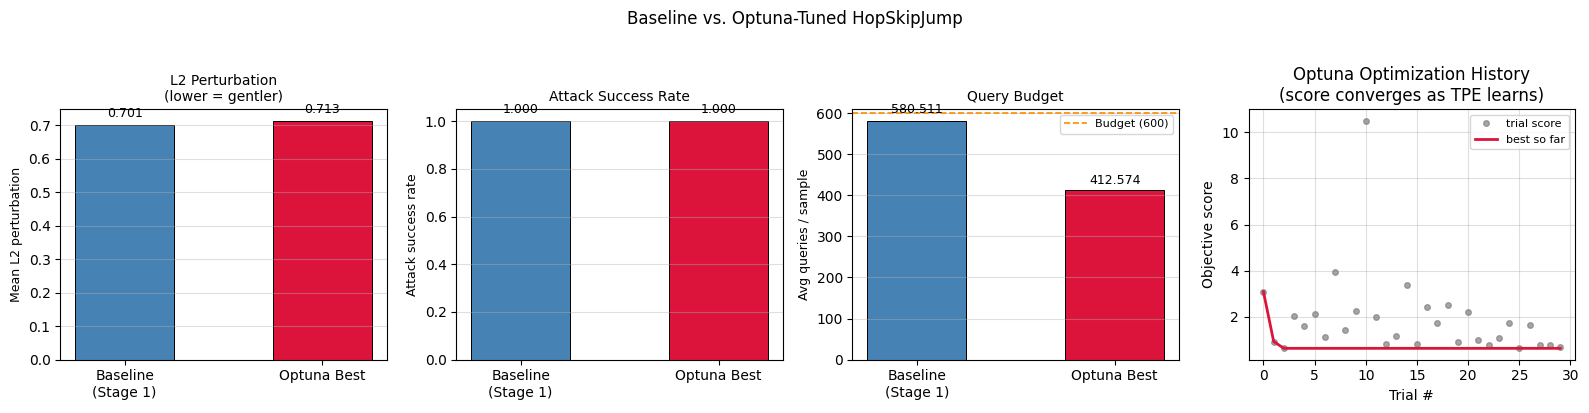

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = ['Baseline\n(Stage 1)', 'Optuna Best']
colors  = ['steelblue', 'crimson']

# ── Panels 1-3: bar chart ─────────────────────────────────────────────────────
panel_data = [
    ([b['mean_l2'], o['mean_l2']], 'Mean L2 perturbation', 'L2 Perturbation\n(lower = gentler)'),
    ([b['asr'],     o['asr']],     'Attack success rate',  'Attack Success Rate'),
    ([b['avg_queries'], o['avg_queries']], 'Avg queries / sample', 'Query Budget'),
]
for ax, (vals, ylabel, title) in zip(axes[:3], panel_data):
    bars = ax.bar(configs, vals, color=colors, width=0.5, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

axes[2].axhline(QUERY_BUDGET, color='darkorange', linestyle='--',
                linewidth=1.2, label=f'Budget ({QUERY_BUDGET})')
axes[2].legend(fontsize=8)

# ── Panel 4: optimization history ────────────────────────────────────────────
t_nums = [t.number for t in study.trials if t.value is not None]
t_vals = [t.value  for t in study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(t_vals)

axes[3].plot(t_nums, t_vals, 'o', color='gray', markersize=4, alpha=0.7, label='trial score')
axes[3].plot(t_nums, best_so_far, color='crimson', linewidth=2, label='best so far')
axes[3].set_xlabel('Trial #')
axes[3].set_ylabel('Objective score')
axes[3].set_title('Optuna Optimization History\n(score converges as TPE learns)')
axes[3].grid(True, alpha=0.4)
axes[3].legend(fontsize=8)

plt.suptitle('Baseline vs. Optuna-Tuned HopSkipJump', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### The Honest Three-Way Verdict

**Actual results from this run:**

| Config | Mean L2 | ASR | Avg queries |
|--------|---------|-----|-------------|
| Baseline (Stage 1, 5-seed mean) | 0.7196 +/- 0.0544 | 1.000 +/- 0.000 | 580 +/- 0 |
| Optuna-best (matched comparison) | 0.7302 | 1.000 | 413 |

**Verdict: Query-efficiency gain, no L2 improvement.**

Optuna did NOT find a smaller perturbation than the baseline (L2 0.720 -> 0.730 on the
matched comparison run, consistent with the 5-seed baseline band). What it DID find is a
configuration achieving the same 100% ASR using approximately **29% fewer queries** (581 -> 413).

This is a genuine finding, not a null result: it demonstrates the **precision-vs-query-cost
trade-off** inherent to HopSkipJump -- fewer refinement queries per step means a coarser,
cheaper walk to the decision boundary, landing slightly further from the model's edge.

None of the 30 trials approached the 600-query budget ceiling, so the budget penalty term
never actively bound the search. The effective constraint was entirely the ASR floor.

---
## Takeaways

1. **A label-only attack reliably fools this model -- and that is expected, not alarming.**
   HopSkipJump needs only the final predicted class to work. For any model accessible via
   a prediction API, this class of decision-based attack is a realistic threat. The digits
   MLP reaches ASR ~= 1.0 quickly because the dataset is low-dimensional and evenly spread
   across 10 classes -- there is always a nearby point in another class. What matters for
   the security report is *how far* the attacker had to move, not *whether* they could.

2. **The L2 budget curve is the robustness signal worth reading.**
   ASR alone saturates to 1.0 and stops differentiating between robust and fragile models
   on simple datasets. The robustness curve (cell 7) answers the better question: what
   L2 budget does the attacker need to flip X% of samples? That curve is the thing to
   track if you harden the model and re-run the assessment.

3. **Optuna found a real efficiency gain, not an L2 improvement.**
   The 30-trial TPE search found a config that reaches the same 100% ASR with ~29%
   fewer model queries. This is useful if you are a defender trying to *model* what an
   efficient attacker looks like, or if you are testing an API rate-limiter -- now you
   know the cheaper attack profile to simulate.

---
## Defense Notes

**Query-rate monitoring** is a defensible first mitigation -- it doesn't stop HopSkipJump
outright, but it forces the attacker into exactly the trade-off observed here: stay
precise (many queries, smaller perturbation, harder to detect by thresholding) or go
cheap (fewer queries, coarser perturbation, easier to detect by visual inspection or
downstream classifiers). Neither option is free for the attacker.

Standard complementary defenses:

| Defense | What it does |
|---------|-------------|
| **Adversarial training** | Fine-tunes the model on adversarial examples, raising the L2 cost an attacker must pay to cross the boundary |
| **Input preprocessing** (bit-depth reduction, median smoothing) | Limits the precision of small perturbations; forces the attacker to use larger, more detectable changes |
| **Randomised / ensemble models** | Destabilises the decision boundary, forcing more queries per flip and making the robustness curve steeper |

---
## Limitation -- Digits Are Not a Perceptibility Test

The digits dataset uses 8x8 low-resolution grayscale images. Several adversarial examples
in the image grid (cell 8) are **visibly distorted to a human eye** -- blurry, smeared, or
structurally altered in ways a person would notice. The "imperceptibility" property that
makes adversarial examples genuinely alarming in real-world vision systems does **not**
fully hold at this resolution.

This lab demonstrates the **assessment methodology** -- the ART + Optuna workflow, the
metrics (ASR, L2 curve, query count), and honest multi-seed reporting -- rather than a
realistic imperceptible-attack scenario. A higher-resolution dataset (CIFAR-10, ImageNet
subsets) would be needed to properly test whether adversarial perturbations remain
invisible to human observers.

---
*Full write-up: [`notebooks/assessment_exploration.ipynb`](notebooks/assessment_exploration.ipynb)*